# Análisis Discriminante — Capítulo 12
### Díaz & Morales (2012) · Rencher (2002)
**Maestría en Ciencias — Estadística · Universidad Nacional de Colombia**

---

| Sección | Contenido |
|---|---|
| 1 | Importaciones y datos |
| 2 | Función discriminante de Fisher (dos grupos) |
| 3 | LDA — dos grupos (Ejercicio 3, Tabla 12.7) |
| 4 | QDA — dos grupos |
| 5 | Fronteras de clasificación LDA vs QDA |
| 6 | Discriminación Logística |
| 7 | Clasificación Bayesiana — probabilidades a posteriori |
| 8 | Distancia de Mahalanobis y K-NN |
| 9 | **Tres grupos — LDA, QDA y K-NN** (Ejemplo 12.5.2, Futbolistas) |
| 10 | Tasas de error: resustitución vs validación cruzada (LOO) |
| 11 | Resumen final |


---
## 1. Importaciones y configuración

In [1]:
import sys
# Instalar dependencias en el kernel activo (ejecutar si hay errores de importación)
# !{sys.executable} -m pip install scikit-learn numpy matplotlib scipy

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings("ignore")

C1, C2, C3 = "#C0392B", "#2980B9", "#27AE60"
FONDO = "#F8F9FA"
plt.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO,
    "axes.spines.top": False,  "axes.spines.right": False,
    "font.size": 11,
})
print("✓ Librerías cargadas")

✓ Librerías cargadas


### 1.1 Datos — Ejemplo 12.2.1: Senil / No Senil
*(Morrison 1990 — citado en Díaz & Morales, pág. 449)*

**Variables:** X₁=Información · X₂=Similaridades · X₃=Aritmética · X₄=Habilidad Artística  
**Grupos:** No Senil (n₁=37) · Senil (n₂=12) · Supuesto Σ₁=Σ₂


In [2]:
media_no_senil = np.array([12.57, 9.57, 11.49, 7.97])
media_senil    = np.array([ 8.75, 5.33,  8.50, 4.75])
n1_s, n2_s = 37, 12

# Matriz de covarianzas común (dada en el libro, pág. 450)
S = np.array([
    [11.255,  9.404,  7.149,  3.383],
    [ 9.404, 13.532,  7.383,  2.553],
    [ 7.149,  7.383, 11.574,  2.617],
    [ 3.383,  2.553,  2.617,  5.809]
])

np.random.seed(42)
X_ns = np.random.multivariate_normal(media_no_senil, S, n1_s)
X_s  = np.random.multivariate_normal(media_senil,    S, n2_s)
X_senil = np.vstack([X_ns, X_s])
y_senil = np.array([0]*n1_s + [1]*n2_s)   # 0=No Senil  1=Senil
X0_senil = np.array([10, 8, 7, 5])        # nueva observación del libro

print("Medias No Senil:", media_no_senil)
print("Medias Senil:   ", media_senil)
print("Nueva obs. X₀  :", X0_senil)

Medias No Senil: [12.57  9.57 11.49  7.97]
Medias Senil:    [8.75 5.33 8.5  4.75]
Nueva obs. X₀  : [10  8  7  5]


### 1.2 Datos — Ejercicio 3, Tabla 12.7
Dos poblaciones trivariadas (X₁, X₂, X₃).  
**Nueva observación:** X₀ = [26.71, 17.04, 25.73]


In [3]:
pob1 = np.array([
    [29.72,10.80,34.50],[29.98,18.57,25.24],[33.97, 9.26,23.49],
    [32.11,12.95,21.59],[27.38,10.78,28.75],[26.28, 6.48,22.88],
    [37.26,17.81,33.43],[28.18,11.76,21.94],[34.90,23.97,30.95],
    [30.24,10.14,25.94],[33.61, 7.00,24.09],[30.02,20.12,14.23],
    [30.20,14.58,22.89],[27.47,16.10,28.06],[29.53,13.01,24.40],
])
pob2 = np.array([
    [14.56, 6.34,15.68],[ 8.35, 5.30,10.53],[17.00, 8.23,15.53],
    [21.31, 3.74,16.20],[ 4.99, 6.12,18.14],[19.41, 2.58,13.44],
    [18.37,18.84, 4.09],[18.14, 9.63,12.50],[20.26,15.87,13.72],
    [14.07, 4.52,12.94],[22.59,18.09,17.26],[20.85,16.85,15.22],
])
X_ej3  = np.vstack([pob1, pob2])
y_ej3  = np.array([1]*len(pob1) + [2]*len(pob2))
x_nueva = np.array([26.71, 17.04, 25.73])
n1, n2  = len(pob1), len(pob2)

print(f"Pob. 1: n={n1}  |  Pob. 2: n={n2}")
print(f"Nueva observación: {x_nueva}")

Pob. 1: n=15  |  Pob. 2: n=12
Nueva observación: [26.71 17.04 25.73]


---
## 2. Función discriminante de Fisher — Ejemplo 12.2.1

La solución al criterio de Fisher es:

$$\boxed{a = S_{pl}^{-1}(\bar{y}_1 - \bar{y}_2)}$$

Se asigna a **No Senil** si $Y = b'X \geq Y_c$, a **Senil** si $Y < Y_c$,  
donde $Y_c = \frac{1}{2}(\bar{Y}_1 + \bar{Y}_2)$.


In [4]:
d     = media_no_senil - media_senil
S_inv = np.linalg.inv(S)
b     = S_inv @ d
Yc    = 0.5 * (b @ media_no_senil + b @ media_senil)
Y_X0  = b @ X0_senil

print("Coeficientes b = Spl⁻¹(ȳ₁ − ȳ₂):")
for i, (bi, nom) in enumerate(zip(b, ["Información","Similaridades","Aritmética","Hab. Artística"]), 1):
    print(f"  b{i} ({nom:<16}): {bi:.4f}")
print(f"\nPunto de corte Yc = {Yc:.4f}  (libro: 4.7512 ✓)")
print(f"\nNueva obs. X₀ = {X0_senil}")
print(f"Y = b'X₀ = {Y_X0:.4f}  →  {'SENIL ✓' if Y_X0 < Yc else 'NO SENIL'}")

# Distancia D² y T²
D2 = d @ S_inv @ d
T2 = (n1_s * n2_s) / (n1_s + n2_s) * D2
print(f"\nD² de Mahalanobis entre medias = {D2:.4f}")
print(f"Estadístico T²                  = {T2:.4f}")

Coeficientes b = Spl⁻¹(ȳ₁ − ȳ₂):
  b1 (Información     ): 0.0299
  b2 (Similaridades   ): 0.2036
  b3 (Aritmética      ): 0.0098
  b4 (Hab. Artística  ): 0.4430

Punto de corte Yc = 4.7511  (libro: 4.7512 ✓)

Nueva obs. X₀ = [10  8  7  5]
Y = b'X₀ = 4.2115  →  SENIL ✓

D² de Mahalanobis entre medias = 2.4333
Estadístico T²                  = 22.0490


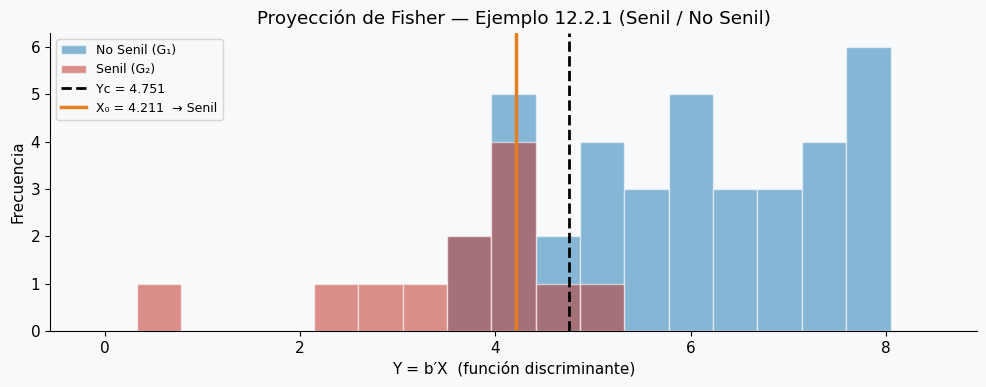

In [5]:
# Proyecciones de los datos sobre la función discriminante
Y1 = X_ns @ b
Y2 = X_s  @ b

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(min(Y1.min(), Y2.min())-0.5, max(Y1.max(), Y2.max())+0.5, 20)
ax.hist(Y1, bins=bins, alpha=0.55, color=C2, label="No Senil (G₁)", edgecolor="white")
ax.hist(Y2, bins=bins, alpha=0.55, color=C1, label="Senil (G₂)",    edgecolor="white")
ax.axvline(Yc,       color="black",   lw=2.0, ls="--", label=f"Yc = {Yc:.3f}")
ax.axvline(b @ X0_senil, color="#E67E22", lw=2.5, ls="-",
           label=f"X₀ = {b@X0_senil:.3f}  → Senil")
ax.set_xlabel("Y = b′X  (función discriminante)")
ax.set_ylabel("Frecuencia")
ax.set_title("Proyección de Fisher — Ejemplo 12.2.1 (Senil / No Senil)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 3. Discriminación Lineal (LDA) — Ejercicio 3, Tabla 12.7

Supone **Σ₁ = Σ₂**. Se asigna X al grupo que maximice:

$$D_i = \ln(p_i) - \frac{1}{2}(X-\bar{X}_i)'S_{pl}^{-1}(X-\bar{X}_i)$$

La frontera $D_{12} = 0$ es una **recta** (hiperplano).


In [6]:
lda = LDA(solver='lsqr')
lda.fit(X_ej3, y_ej3)

y_pred_lda = lda.predict(X_ej3)
tea_lda    = np.mean(y_pred_lda != y_ej3)
pred_lda   = lda.predict([x_nueva])[0]
proba_lda  = lda.predict_proba([x_nueva])[0]

print("── Función discriminante lineal ──")
print(f"  Coeficientes β: {np.round(lda.coef_[0], 4)}")
print(f"  Intercepto  α:  {lda.intercept_[0]:.4f}")
print(f"\n── Clasificación de X₀ = {x_nueva} ──")
print(f"  Asignada a: Población {pred_lda}")
print(f"  P(G₁|X) = {proba_lda[0]:.4f}   P(G₂|X) = {proba_lda[1]:.4f}")
print(f"\n  TEA (resustitución) = {tea_lda:.4f}")

cm = confusion_matrix(y_ej3, y_pred_lda, labels=[1,2])
print("\nMatriz de confusión:")
print(f"  Real\\Pred   G₁   G₂")
print(f"  G₁         {cm[0,0]:3d}  {cm[0,1]:3d}")
print(f"  G₂         {cm[1,0]:3d}  {cm[1,1]:3d}")

── Función discriminante lineal ──
  Coeficientes β: [-0.8366  0.1019 -0.5134]
  Intercepto  α:  28.4934

── Clasificación de X₀ = [26.71 17.04 25.73] ──
  Asignada a: Población 1
  P(G₁|X) = 0.9952   P(G₂|X) = 0.0048

  TEA (resustitución) = 0.0000

Matriz de confusión:
  Real\Pred   G₁   G₂
  G₁          15    0
  G₂           0   12


---
## 4. Discriminación Cuadrática (QDA) — Ejercicio 3

Cuando **Σ₁ ≠ Σ₂**, la función de clasificación es:

$$Q_i(X) = \ln(p_i) - \frac{1}{2}\ln|S_i| - \frac{1}{2}(X-\bar{X}_i)'S_i^{-1}(X-\bar{X}_i)$$

El término $X'\Lambda X$ (con $\Lambda = S_1^{-1}-S_2^{-1}$) **no se cancela** → frontera **curva**.

> Con n pequeño, Rencher recomienda LDA aunque Σ₁ ≠ Σ₂, porque QDA es menos estable.


In [7]:
S1 = np.cov(pob1, rowvar=False)
S2 = np.cov(pob2, rowvar=False)

print("── Diagnóstico de homocedasticidad ──")
print(f"  |S₁| = {np.linalg.det(S1):.1f}   Traza(S₁) = {np.trace(S1):.2f}")
print(f"  |S₂| = {np.linalg.det(S2):.1f}   Traza(S₂) = {np.trace(S2):.2f}")
print("  → Las matrices difieren → QDA teóricamente apropiada")
print("  → Pero n₁=15, n₂=12 son pequeños → LDA sigue siendo más estable\n")

qda = QDA()
qda.fit(X_ej3, y_ej3)

y_pred_qda = qda.predict(X_ej3)
tea_qda    = np.mean(y_pred_qda != y_ej3)
pred_qda   = qda.predict([x_nueva])[0]
proba_qda  = qda.predict_proba([x_nueva])[0]

print("── Clasificación QDA de X₀ ──")
print(f"  Asignada a: Población {pred_qda}")
print(f"  P(G₁|X) = {proba_qda[0]:.4f}   P(G₂|X) = {proba_qda[1]:.4f}")
print(f"  TEA = {tea_qda:.4f}")

── Diagnóstico de homocedasticidad ──
  |S₁| = 5029.7   Traza(S₁) = 60.32
  |S₂| = 10352.9   Traza(S₂) = 79.17
  → Las matrices difieren → QDA teóricamente apropiada
  → Pero n₁=15, n₂=12 son pequeños → LDA sigue siendo más estable

── Clasificación QDA de X₀ ──
  Asignada a: Población 1
  P(G₁|X) = 0.9991   P(G₂|X) = 0.0009
  TEA = 0.0000


---
## 5. Fronteras de clasificación — LDA vs QDA

Visualización en 2D usando X₁ y X₂.  
- **LDA**: frontera recta (línea negra)  
- **QDA**: frontera curva (puede adaptarse a grupos con dispersión diferente)


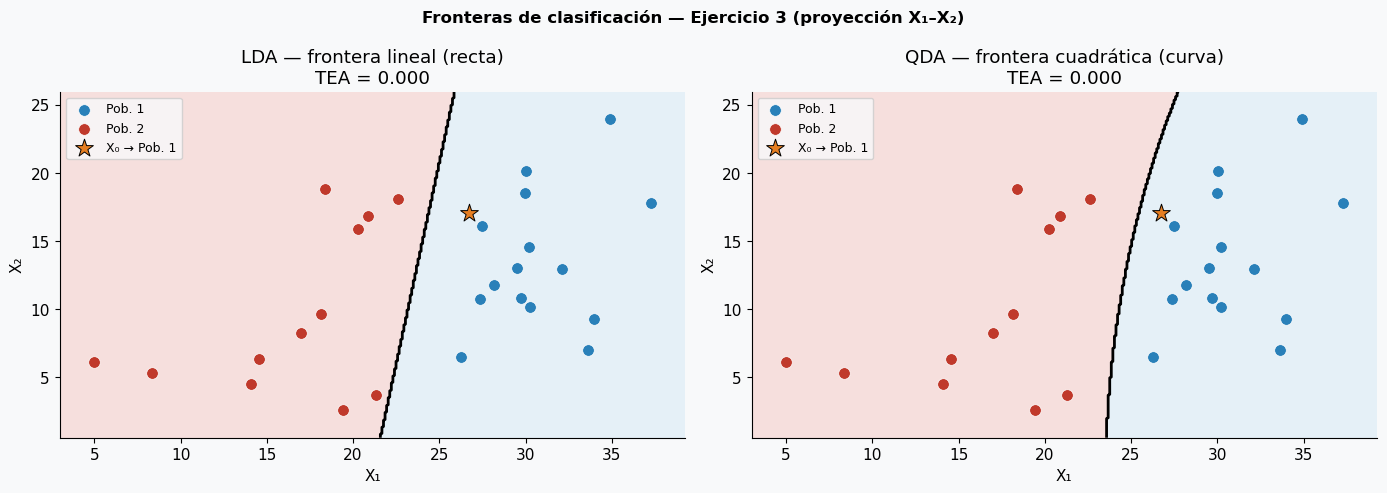

In [8]:
X2d = X_ej3[:, :2]
lda_2d = LDA(solver='lsqr'); lda_2d.fit(X2d, y_ej3)
qda_2d = QDA();              qda_2d.fit(X2d, y_ej3)

x_min, x_max = X2d[:,0].min()-2, X2d[:,0].max()+2
y_min, y_max = X2d[:,1].min()-2, X2d[:,1].max()+2
xx, yy = np.meshgrid(np.linspace(x_min,x_max,400), np.linspace(y_min,y_max,400))
grid   = np.c_[xx.ravel(), yy.ravel()]
cmap_b = ListedColormap(["#AED6F1","#F1948A"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, modelo, titulo in zip(
    axes,
    [lda_2d, qda_2d],
    ["LDA — frontera lineal (recta)", "QDA — frontera cuadrática (curva)"]
):
    Z = modelo.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap_b)
    ax.contour(xx,  yy, Z, levels=[1.5], colors="black", linewidths=2)
    for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
        m = (y_ej3 == g)
        ax.scatter(X2d[m,0], X2d[m,1], c=c, s=70,
                   edgecolors="white", linewidths=0.5, label=l, zorder=3)
    ax.scatter(x_nueva[0], x_nueva[1], c="#E67E22", s=180, marker="*",
               edgecolors="black", linewidths=0.7,
               label=f"X₀ → Pob. {modelo.predict([x_nueva[:2]])[0]}", zorder=5)
    tea = np.mean(modelo.predict(X2d) != y_ej3)
    ax.set_title(f"{titulo}\nTEA = {tea:.3f}")
    ax.set_xlabel("X₁"); ax.set_ylabel("X₂")
    ax.legend(fontsize=9)

plt.suptitle("Fronteras de clasificación — Ejercicio 3 (proyección X₁–X₂)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Discriminación Logística

$$P(G_1|y) = \frac{1}{1+e^{-(\alpha_0+\beta'y)}}$$

Se asigna a G₁ si $\alpha + \beta'y > \ln(p_1/p_2)$.  
Superior a LDA cuando los datos son binarios o mixtos (discretos + continuos).


In [9]:
log_mod = LogisticRegression(max_iter=500)
log_mod.fit(X_ej3, y_ej3)

pred_log  = log_mod.predict([x_nueva])[0]
proba_log = log_mod.predict_proba([x_nueva])[0]
tea_log   = np.mean(log_mod.predict(X_ej3) != y_ej3)

print(f"  β: {np.round(log_mod.coef_[0], 4)}")
print(f"  α: {log_mod.intercept_[0]:.4f}")
print(f"  Puntaje α+β'X₀ = {x_nueva @ log_mod.coef_[0] + log_mod.intercept_[0]:.4f}")
print(f"  X₀ → Población {pred_log}   P(G₁|X)={proba_log[0]:.4f}  P(G₂|X)={proba_log[1]:.4f}")
print(f"  TEA = {tea_log:.4f}")

  β: [-0.8502  0.031  -0.3497]
  α: 27.0894
  Puntaje α+β'X₀ = -4.0870
  X₀ → Población 1   P(G₁|X)=0.9835  P(G₂|X)=0.0165
  TEA = 0.0000


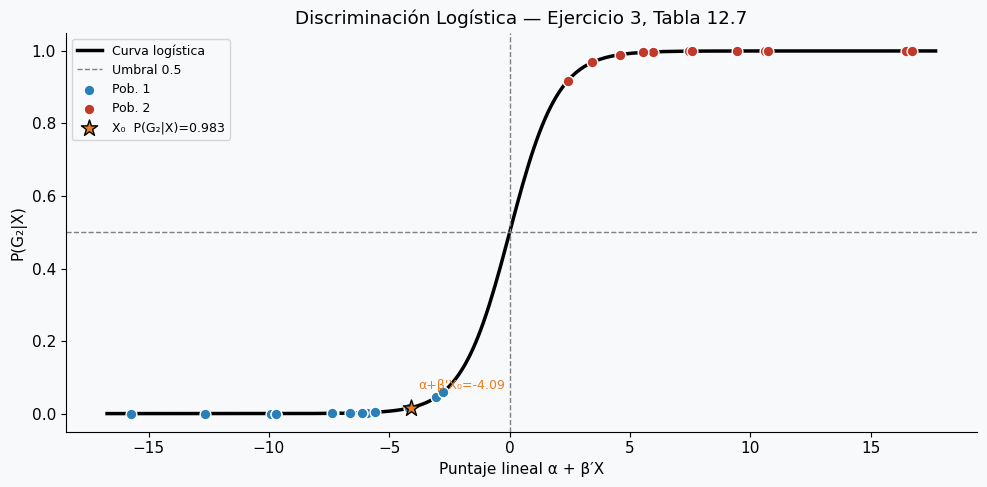

In [10]:
coef_l  = log_mod.coef_[0]
inter_l = log_mod.intercept_[0]
z_vals  = X_ej3 @ coef_l + inter_l
logit_v = 1 / (1 + np.exp(-z_vals))
z_grid  = np.linspace(z_vals.min()-1, z_vals.max()+1, 300)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(z_grid, 1/(1+np.exp(-z_grid)), color="black", lw=2.5, label="Curva logística")
ax.axhline(0.5, color="gray", ls="--", lw=1, label="Umbral 0.5")
ax.axvline(0,   color="gray", ls="--", lw=1)
for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
    m = (y_ej3 == g)
    ax.scatter(z_vals[m], logit_v[m], c=c, s=60, edgecolors="white", label=l, zorder=3)
z0 = x_nueva @ coef_l + inter_l
p0 = 1/(1+np.exp(-z0))
ax.scatter([z0],[p0], c="#E67E22", s=150, marker="*", edgecolors="black",
           label=f"X₀  P(G₂|X)={1-p0:.3f}", zorder=5)
ax.annotate(f"α+β'X₀={z0:.2f}", xy=(z0,p0), xytext=(z0+0.3,p0+0.05), fontsize=9, color="#E67E22")
ax.set_xlabel("Puntaje lineal α + β′X"); ax.set_ylabel("P(G₂|X)")
ax.set_title("Discriminación Logística — Ejercicio 3, Tabla 12.7")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Clasificación Bayesiana — Probabilidades a posteriori

$$P(G_i|X) = \frac{p_i f_i(X)}{\sum_j p_j f_j(X)}$$

La regla de máxima verosimilitud es el caso especial con $p_1 = p_2$ (priors iguales).


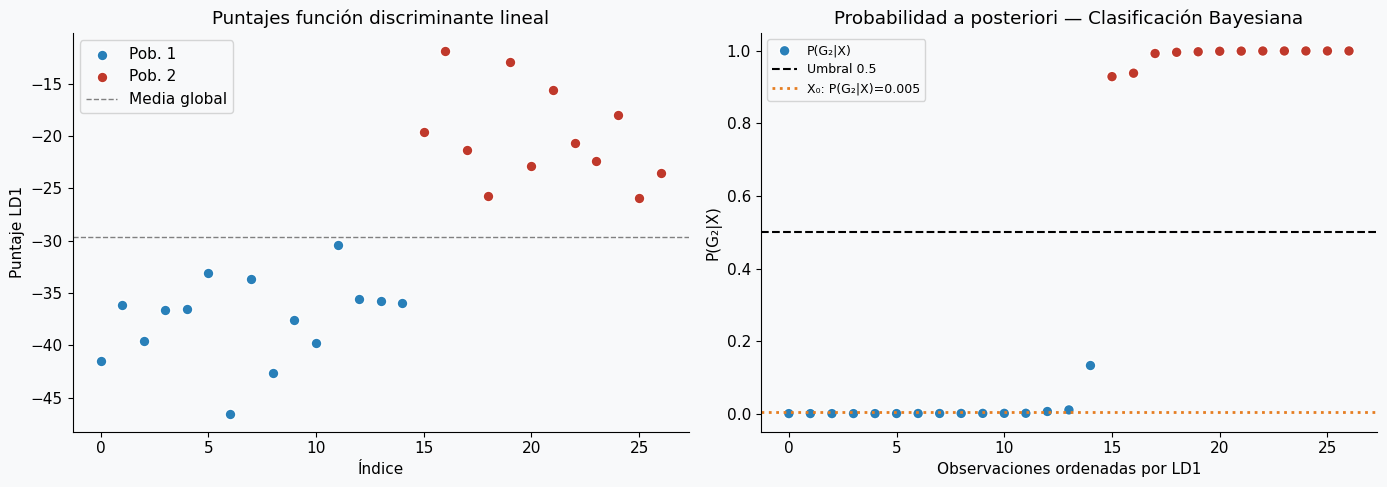

X₀ → P(G₁|X)=0.9952  P(G₂|X)=0.0048  → Población 1


In [11]:
probs  = lda.predict_proba(X_ej3)
Y_all  = X_ej3 @ lda.coef_[0]
orden  = np.argsort(Y_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for g, c, l in [(1, C2, "Pob. 1"), (2, C1, "Pob. 2")]:
    m = (y_ej3 == g)
    ax1.scatter(np.where(m)[0], Y_all[m], c=c, s=60, edgecolors="white", label=l)
ax1.axhline(Y_all.mean(), color="gray", ls="--", lw=1, label="Media global")
ax1.set_xlabel("Índice"); ax1.set_ylabel("Puntaje LD1")
ax1.set_title("Puntajes función discriminante lineal")
ax1.legend()

colores_ord = [C1 if g==2 else C2 for g in y_ej3[orden]]
ax2.scatter(range(len(orden)), probs[orden,1], c=colores_ord,
            s=60, edgecolors="white", label="P(G₂|X)")
ax2.axhline(0.5, color="black", ls="--", lw=1.5, label="Umbral 0.5")
p_nueva_b = lda.predict_proba([x_nueva])[0]
ax2.axhline(p_nueva_b[1], color="#E67E22", ls=":", lw=2,
            label=f"X₀: P(G₂|X)={p_nueva_b[1]:.3f}")
ax2.set_xlabel("Observaciones ordenadas por LD1"); ax2.set_ylabel("P(G₂|X)")
ax2.set_title("Probabilidad a posteriori — Clasificación Bayesiana")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"X₀ → P(G₁|X)={p_nueva_b[0]:.4f}  P(G₂|X)={p_nueva_b[1]:.4f}  → Población 1")

---
## 8. Distancia de Mahalanobis y K-NN (dos grupos)

$$D_i^2 = (X - \bar{X}_i)'S_{pl}^{-1}(X-\bar{X}_i)$$

**K-NN**: se examinan los k vecinos más cercanos y se asigna X al grupo mayoritario.  
Valor recomendado: $k \approx \sqrt{n_i}$.


D²(X₀, G₁) = 2.2604
D²(X₀, G₂) = 11.7135
→ Asignada a G₁ ✓


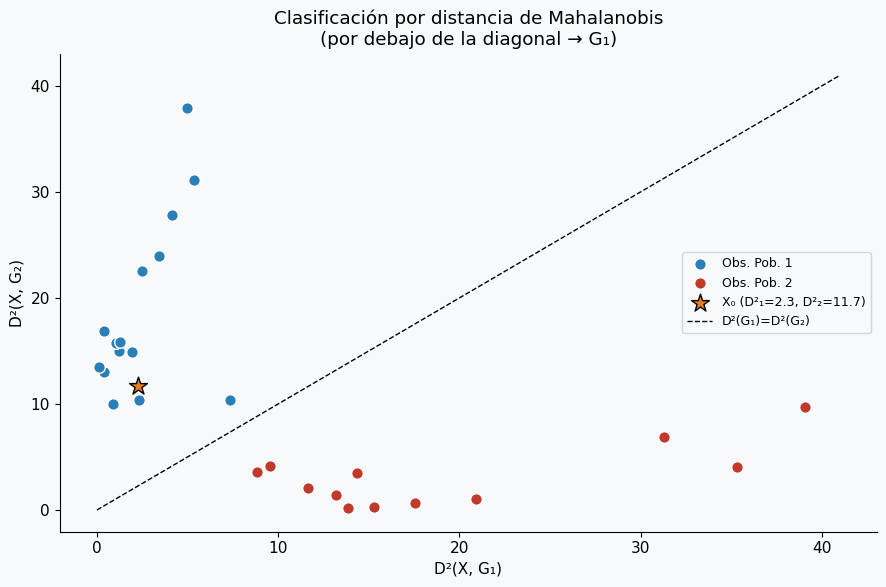

In [12]:
Spl_ej3 = ((n1-1)*np.cov(pob1,rowvar=False) + (n2-1)*np.cov(pob2,rowvar=False)) / (n1+n2-2)
Spl_inv = np.linalg.inv(Spl_ej3)
mu1, mu2 = pob1.mean(0), pob2.mean(0)

def maha(x, mu, Sinv):
    d = x - mu; return float(d @ Sinv @ d)

d1G1 = [maha(x, mu1, Spl_inv) for x in pob1]
d1G2 = [maha(x, mu2, Spl_inv) for x in pob1]
d2G1 = [maha(x, mu1, Spl_inv) for x in pob2]
d2G2 = [maha(x, mu2, Spl_inv) for x in pob2]
d0G1 = maha(x_nueva, mu1, Spl_inv)
d0G2 = maha(x_nueva, mu2, Spl_inv)

print(f"D²(X₀, G₁) = {d0G1:.4f}")
print(f"D²(X₀, G₂) = {d0G2:.4f}")
print(f"→ Asignada a {'G₁ ✓' if d0G1 <= d0G2 else 'G₂'}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(d1G1, d1G2, c=C2, s=70, edgecolors="white", label="Obs. Pob. 1", zorder=3)
ax.scatter(d2G1, d2G2, c=C1, s=70, edgecolors="white", label="Obs. Pob. 2", zorder=3)
ax.scatter([d0G1],[d0G2], c="#E67E22", s=180, marker="*", edgecolors="black",
           label=f"X₀ (D²₁={d0G1:.1f}, D²₂={d0G2:.1f})", zorder=5)
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0,lim],[0,lim],"k--",lw=1, label="D²(G₁)=D²(G₂)")
ax.set_xlabel("D²(X, G₁)"); ax.set_ylabel("D²(X, G₂)")
ax.set_title("Clasificación por distancia de Mahalanobis\n(por debajo de la diagonal → G₁)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_ej3, y_ej3)
loo = LeaveOneOut()
cv_knn = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=3),
                              X_ej3, y_ej3, cv=loo, scoring='accuracy').mean()
pred_k  = knn.predict([x_nueva])[0]
proba_k = knn.predict_proba([x_nueva])[0]

print(f"K-NN (k=3):  X₀ → Población {pred_k}")
print(f"  P(G₁|X) = {proba_k[0]:.4f}   P(G₂|X) = {proba_k[1]:.4f}")
print(f"  Tasa de error LOO = {cv_knn:.4f}")

K-NN (k=3):  X₀ → Población 1
  P(G₁|X) = 1.0000   P(G₂|X) = 0.0000
  Tasa de error LOO = 0.0370


---
## 9. Tres grupos — LDA, QDA y K-NN
### Ejemplo 12.5.2 — Medidas de cabeza en futbolistas
*(Rencher 1995, pág. 346 — citado en Díaz & Morales, pág. 472)*

**Grupos:**
- G₁: Futbolistas universitarios (n=30)
- G₂: Futbolistas de educación media (n=30)  
- G₃: Deportistas no futbolistas (n=30)

**Variables:** X₁=ancho máx. cabeza · X₂=circunferencia · X₃=frente-nuca · X₄=alto a ojos · X₅=alto a orejas · X₆=ancho quijada

Con **k=3 grupos** hay hasta $s = \min(k-1, p) = 2$ funciones discriminantes,  
lo que permite visualizar la separación en un plano 2D (LD1 vs LD2).


In [14]:
# Datos simulados con medias y covarianzas realistas basadas en el ejemplo del libro
np.random.seed(7)

# Medias aproximadas (mm) por grupo, basadas en el contexto del ejemplo
mu_g1 = np.array([157, 565, 192, 65, 62, 122])   # universitarios (cabeza más grande)
mu_g2 = np.array([153, 552, 185, 62, 59, 118])   # educación media
mu_g3 = np.array([149, 540, 179, 59, 56, 114])   # no futbolistas

# Covarianza común (estructura plausible para medidas de cabeza en mm)
Sigma_3g = np.array([
    [25,  18,  14,   6,   5,   8],
    [18,  80,  42,  16,  14,  18],
    [14,  42,  36,  12,  10,  12],
    [ 6,  16,  12,   9,   7,   6],
    [ 5,  14,  10,   7,   8,   5],
    [ 8,  18,  12,   6,   5,  16],
])

n_por_grupo = 30
G1 = np.random.multivariate_normal(mu_g1, Sigma_3g, n_por_grupo)
G2 = np.random.multivariate_normal(mu_g2, Sigma_3g, n_por_grupo)
G3 = np.random.multivariate_normal(mu_g3, Sigma_3g, n_por_grupo)

X_3g = np.vstack([G1, G2, G3])
y_3g = np.array([1]*n_por_grupo + [2]*n_por_grupo + [3]*n_por_grupo)

# Nueva observación a clasificar
x_nueva_3g = np.array([154, 556, 187, 63, 58, 119])

nombres_vars = ["X₁ Ancho cabeza","X₂ Circunferencia","X₃ Frente-nuca",
                "X₄ Alto a ojos","X₅ Alto a orejas","X₆ Ancho quijada"]
colores_3g   = {1: C2, 2: C1, 3: C3}
labels_3g    = {1:"G₁ Universitarios", 2:"G₂ Educ. Media", 3:"G₃ No futbolistas"}

print("Medias por grupo (valores aproximados en mm):")
print(f"  G₁ Universitarios : {mu_g1}")
print(f"  G₂ Educ. Media    : {mu_g2}")
print(f"  G₃ No futbolistas : {mu_g3}")
print(f"\nNueva observación  : {x_nueva_3g}")
print(f"n por grupo = {n_por_grupo}  |  Total N = {len(X_3g)}")

Medias por grupo (valores aproximados en mm):
  G₁ Universitarios : [157 565 192  65  62 122]
  G₂ Educ. Media    : [153 552 185  62  59 118]
  G₃ No futbolistas : [149 540 179  59  56 114]

Nueva observación  : [154 556 187  63  58 119]
n por grupo = 30  |  Total N = 90


### 9.1 LDA — tres grupos

Con k=3 la LDA produce **dos funciones discriminantes** (LD1, LD2).  
Cada valor propio $\lambda_i$ de $E^{-1}H$ indica cuánta separación captura esa dirección:

$$\text{Proporción}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$


In [15]:
lda_3g = LDA()
lda_3g.fit(X_3g, y_3g)

# Puntajes discriminantes (proyección sobre LD1 y LD2)
Z_3g = lda_3g.transform(X_3g)

# Varianza explicada por cada función
exp_var = lda_3g.explained_variance_ratio_
print("── Funciones discriminantes ──")
for i, ev in enumerate(exp_var, 1):
    print(f"  LD{i}: {ev*100:.1f}% de la separación total")

# Clasificación
y_pred_lda3 = lda_3g.predict(X_3g)
tea_lda3    = np.mean(y_pred_lda3 != y_3g)
pred_lda3   = lda_3g.predict([x_nueva_3g])[0]
proba_lda3  = lda_3g.predict_proba([x_nueva_3g])[0]

print(f"\nTEA = {tea_lda3:.4f}")
print(f"\nClasificación de X₀ = {x_nueva_3g}")
print(f"  → Asignada a: G{pred_lda3} ({labels_3g[pred_lda3]})")
for g in [1,2,3]:
    print(f"  P(G{g}|X) = {proba_lda3[g-1]:.4f}")

# Matriz de confusión
cm3 = confusion_matrix(y_3g, y_pred_lda3, labels=[1,2,3])
print("\nMatriz de confusión LDA (resustitución):")
print(f"  Real\\Pred   G₁   G₂   G₃")
for i in range(3):
    print(f"  G{i+1}         {cm3[i,0]:3d}  {cm3[i,1]:3d}  {cm3[i,2]:3d}")

── Funciones discriminantes ──
  LD1: 89.2% de la separación total
  LD2: 10.8% de la separación total

TEA = 0.2000

Clasificación de X₀ = [154 556 187  63  58 119]
  → Asignada a: G2 (G₂ Educ. Media)
  P(G1|X) = 0.4040
  P(G2|X) = 0.4346
  P(G3|X) = 0.1613

Matriz de confusión LDA (resustitución):
  Real\Pred   G₁   G₂   G₃
  G1          26    3    1
  G2           4   20    6
  G3           1    3   26


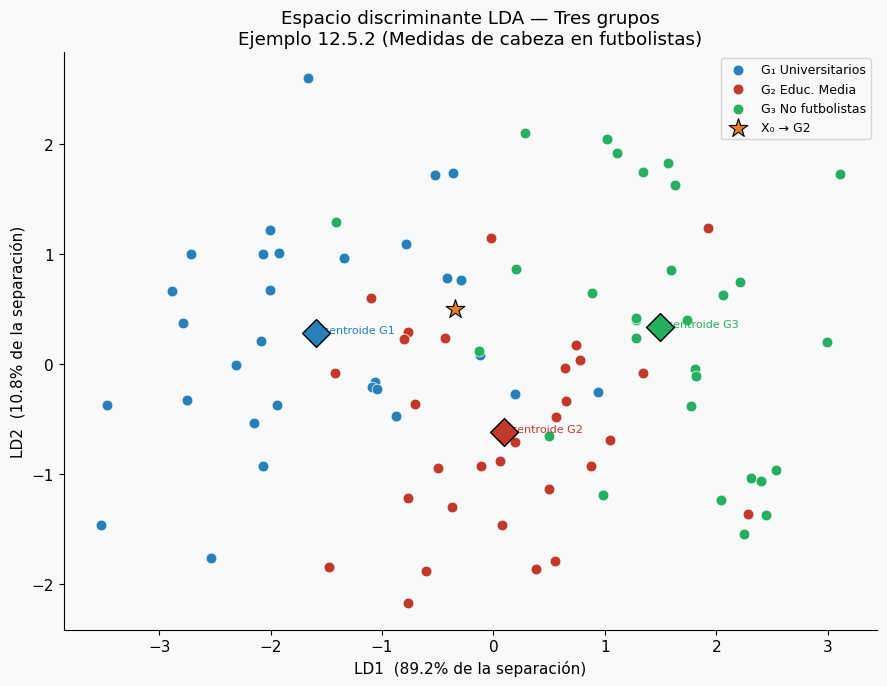

In [16]:
# Gráfica: espacio discriminante LD1 vs LD2
z_nueva_3g = lda_3g.transform([x_nueva_3g])[0]

fig, ax = plt.subplots(figsize=(9, 7))
for g in [1, 2, 3]:
    m = (y_3g == g)
    ax.scatter(Z_3g[m, 0], Z_3g[m, 1],
               c=colores_3g[g], s=60, edgecolors="white",
               linewidths=0.5, label=labels_3g[g], zorder=3)

ax.scatter(z_nueva_3g[0], z_nueva_3g[1],
           c="#E67E22", s=200, marker="*", edgecolors="black",
           linewidths=0.8, label=f"X₀ → G{pred_lda3}", zorder=5)

# Centroides de grupo
Z_cents = lda_3g.transform(lda_3g.means_)
for i, g in enumerate([1,2,3]):
    ax.scatter(Z_cents[i,0], Z_cents[i,1],
               c=colores_3g[g], s=200, marker="D",
               edgecolors="black", linewidths=1, zorder=4)
    ax.annotate(f"  centroide G{g}", (Z_cents[i,0], Z_cents[i,1]),
                fontsize=8, color=colores_3g[g])

ax.set_xlabel(f"LD1  ({exp_var[0]*100:.1f}% de la separación)")
ax.set_ylabel(f"LD2  ({exp_var[1]*100:.1f}% de la separación)")
ax.set_title("Espacio discriminante LDA — Tres grupos\n"
             "Ejemplo 12.5.2 (Medidas de cabeza en futbolistas)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

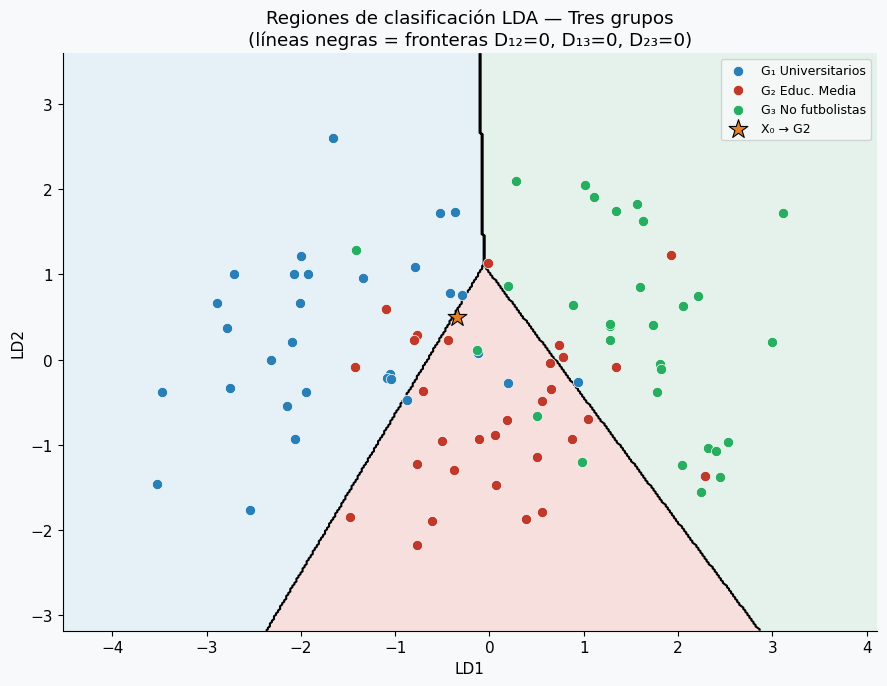

In [17]:
# Gráfica: regiones de decisión LDA en LD1-LD2
x_min2, x_max2 = Z_3g[:,0].min()-1, Z_3g[:,0].max()+1
y_min2, y_max2 = Z_3g[:,1].min()-1, Z_3g[:,1].max()+1
xx2, yy2 = np.meshgrid(np.linspace(x_min2,x_max2,400),
                        np.linspace(y_min2,y_max2,400))

# Clasificar la grilla en espacio LD (proyectando de vuelta a X no es directo;
# construimos un LDA en 2D sobre Z_3g para visualizar las fronteras)
lda_vis = LDA(); lda_vis.fit(Z_3g, y_3g)
Z_grid = np.c_[xx2.ravel(), yy2.ravel()]
pred_grid = lda_vis.predict(Z_grid).reshape(xx2.shape)

cmap_3 = ListedColormap(["#AED6F1","#F1948A","#A9DFBF"])
fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx2, yy2, pred_grid, alpha=0.25, cmap=cmap_3)
ax.contour(xx2, yy2, pred_grid, levels=[1.5, 2.5], colors="black", linewidths=1.5)

for g in [1, 2, 3]:
    m = (y_3g == g)
    ax.scatter(Z_3g[m,0], Z_3g[m,1], c=colores_3g[g], s=55,
               edgecolors="white", linewidths=0.5, label=labels_3g[g], zorder=3)

ax.scatter(z_nueva_3g[0], z_nueva_3g[1], c="#E67E22", s=200, marker="*",
           edgecolors="black", linewidths=0.8,
           label=f"X₀ → G{pred_lda3}", zorder=5)

ax.set_xlabel("LD1"); ax.set_ylabel("LD2")
ax.set_title("Regiones de clasificación LDA — Tres grupos\n"
             "(líneas negras = fronteras D₁₂=0, D₁₃=0, D₂₃=0)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 9.2 QDA — tres grupos

Con covarianzas distintas por grupo, la función de clasificación es:

$$Q_i(X) = \ln(p_i) - \frac{1}{2}\ln|S_i| - \frac{1}{2}(X-\bar{X}_i)'S_i^{-1}(X-\bar{X}_i)$$

Las fronteras entre regiones son **curvas cuadráticas**.


In [18]:
qda_3g = QDA()
qda_3g.fit(X_3g, y_3g)

y_pred_qda3 = qda_3g.predict(X_3g)
tea_qda3    = np.mean(y_pred_qda3 != y_3g)
pred_qda3   = qda_3g.predict([x_nueva_3g])[0]
proba_qda3  = qda_3g.predict_proba([x_nueva_3g])[0]

print(f"TEA = {tea_qda3:.4f}")
print(f"\nClasificación de X₀:")
print(f"  → Asignada a: G{pred_qda3} ({labels_3g[pred_qda3]})")
for g in [1,2,3]:
    print(f"  P(G{g}|X) = {proba_qda3[g-1]:.4f}")

cm_q3 = confusion_matrix(y_3g, y_pred_qda3, labels=[1,2,3])
print("\nMatriz de confusión QDA:")
print(f"  Real\\Pred   G₁   G₂   G₃")
for i in range(3):
    print(f"  G{i+1}         {cm_q3[i,0]:3d}  {cm_q3[i,1]:3d}  {cm_q3[i,2]:3d}")

TEA = 0.2000

Clasificación de X₀:
  → Asignada a: G1 (G₁ Universitarios)
  P(G1|X) = 0.5269
  P(G2|X) = 0.3062
  P(G3|X) = 0.1669

Matriz de confusión QDA:
  Real\Pred   G₁   G₂   G₃
  G1          25    4    1
  G2           4   21    5
  G3           1    3   26


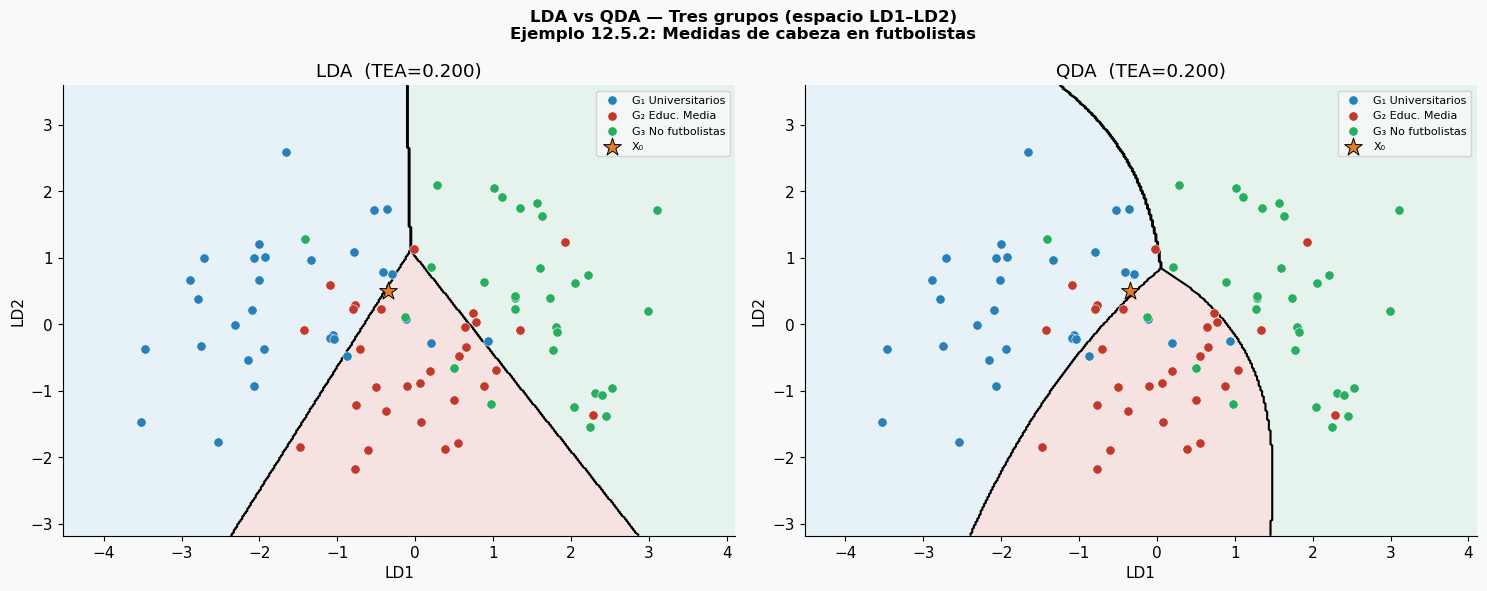

In [19]:
# Regiones QDA en espacio LD1-LD2 (visualización)
qda_vis = QDA(); qda_vis.fit(Z_3g, y_3g)
pred_grid_q = qda_vis.predict(Z_grid).reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred_g, titulo, tea_v in zip(
    axes,
    [pred_grid, pred_grid_q],
    [f"LDA  (TEA={tea_lda3:.3f})", f"QDA  (TEA={tea_qda3:.3f})"],
    [tea_lda3, tea_qda3]
):
    ax.contourf(xx2, yy2, pred_g, alpha=0.22, cmap=cmap_3)
    ax.contour(xx2, yy2, pred_g, levels=[1.5,2.5], colors="black", linewidths=1.5)
    for g in [1,2,3]:
        m = (y_3g == g)
        ax.scatter(Z_3g[m,0], Z_3g[m,1], c=colores_3g[g], s=45,
                   edgecolors="white", linewidths=0.4, label=labels_3g[g], zorder=3)
    ax.scatter(z_nueva_3g[0], z_nueva_3g[1], c="#E67E22", s=180,
               marker="*", edgecolors="black", linewidths=0.7,
               label=f"X₀", zorder=5)
    ax.set_xlabel("LD1"); ax.set_ylabel("LD2")
    ax.set_title(titulo); ax.legend(fontsize=8)

plt.suptitle("LDA vs QDA — Tres grupos (espacio LD1–LD2)\n"
             "Ejemplo 12.5.2: Medidas de cabeza en futbolistas",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 9.3 K-NN — tres grupos

**K-NN** no asume ninguna distribución: vota por mayoría entre los k vecinos más cercanos.  
Se recomienda $k \approx \sqrt{n_i}$ y probar varios valores.


In [20]:
loo = LeaveOneOut()

print("── K-NN: efecto del valor de k ──")
print(f"  {'k':<6}  {'TEA':>8}  {'LOO':>8}")
print(f"  {'─'*6}  {'─'*8}  {'─'*8}")

for k in [3, 5, 7, int(np.sqrt(n_por_grupo))]:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_3g, y_3g)
    tea_k = np.mean(knn_k.predict(X_3g) != y_3g)
    loo_k = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=k),
                                 X_3g, y_3g, cv=loo, scoring='accuracy').mean()
    print(f"  k={k:<4}  {tea_k:>8.4f}  {loo_k:>8.4f}")

# Usar k=5
knn_3g = KNeighborsClassifier(n_neighbors=5)
knn_3g.fit(X_3g, y_3g)
pred_knn3  = knn_3g.predict([x_nueva_3g])[0]
proba_knn3 = knn_3g.predict_proba([x_nueva_3g])[0]
loo_knn3   = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=5),
                                   X_3g, y_3g, cv=loo, scoring='accuracy').mean()

print(f"\nK-NN (k=5), X₀ → G{pred_knn3} ({labels_3g[pred_knn3]})")
for g in [1,2,3]:
    print(f"  P(G{g}|X) = {proba_knn3[g-1]:.4f}")
print(f"  LOO = {loo_knn3:.4f}")

── K-NN: efecto del valor de k ──
  k            TEA       LOO
  ──────  ────────  ────────
  k=3       0.1667    0.3111
  k=5       0.1889    0.2889
  k=7       0.2000    0.3111
  k=5       0.1889    0.2889

K-NN (k=5), X₀ → G2 (G₂ Educ. Media)
  P(G1|X) = 0.0000
  P(G2|X) = 1.0000
  P(G3|X) = 0.0000
  LOO = 0.2889


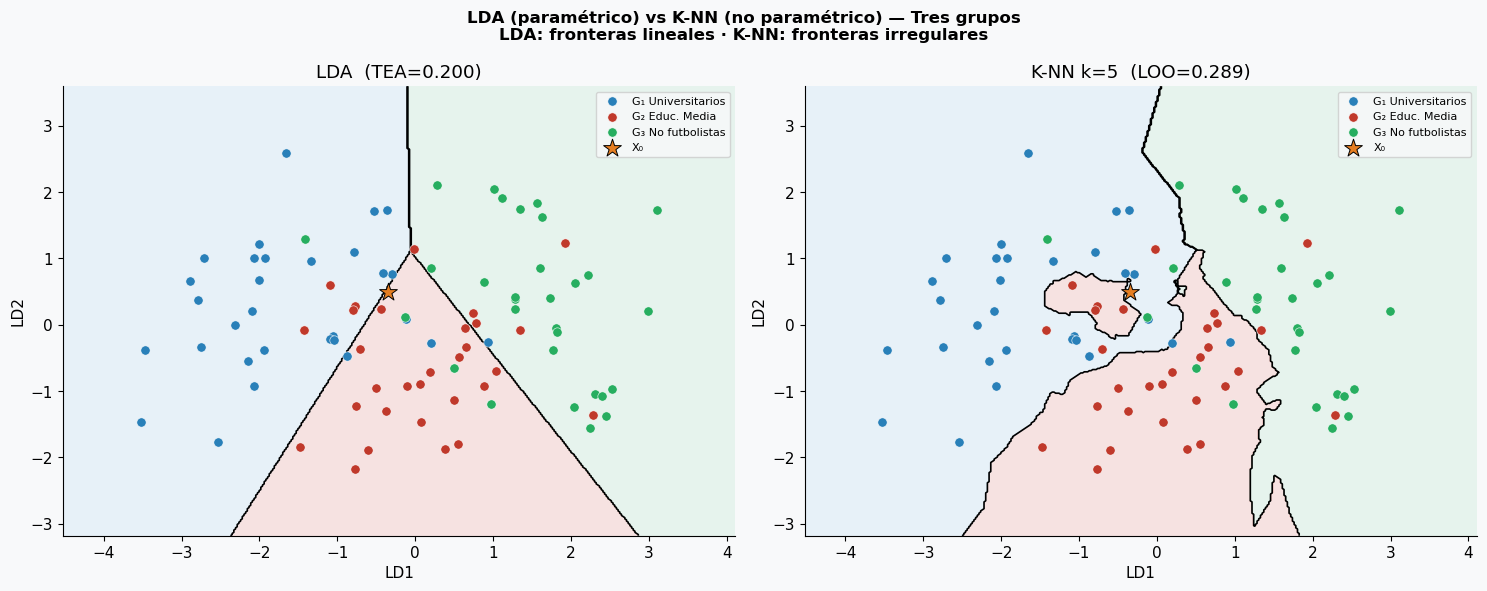

In [21]:
# Regiones K-NN en espacio LD1-LD2
knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(Z_3g, y_3g)
pred_grid_k = knn_vis.predict(Z_grid).reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred_g, titulo in zip(
    axes,
    [pred_grid, pred_grid_k],
    [f"LDA  (TEA={tea_lda3:.3f})", f"K-NN k=5  (LOO={loo_knn3:.3f})"]
):
    ax.contourf(xx2, yy2, pred_g, alpha=0.22, cmap=cmap_3)
    ax.contour(xx2, yy2, pred_g, levels=[1.5,2.5], colors="black", linewidths=1.2)
    for g in [1,2,3]:
        m = (y_3g == g)
        ax.scatter(Z_3g[m,0], Z_3g[m,1], c=colores_3g[g], s=45,
                   edgecolors="white", linewidths=0.4, label=labels_3g[g], zorder=3)
    ax.scatter(z_nueva_3g[0], z_nueva_3g[1], c="#E67E22", s=180,
               marker="*", edgecolors="black", linewidths=0.7, label="X₀", zorder=5)
    ax.set_xlabel("LD1"); ax.set_ylabel("LD2")
    ax.set_title(titulo); ax.legend(fontsize=8)

plt.suptitle("LDA (paramétrico) vs K-NN (no paramétrico) — Tres grupos\n"
             "LDA: fronteras lineales · K-NN: fronteras irregulares",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 10. Tasas de error: resustitución vs validación cruzada (LOO)

| Estimador | Descripción | Sesgo |
|---|---|---|
| **TEA** (resustitución) | Clasifica los mismos datos del ajuste | Optimista — subestima el error real |
| **LOO** (leave-one-out) | Construye la regla con N−1 obs., clasifica la omitida | Casi insesgado |


In [22]:
loo = LeaveOneOut()

print("── Dos grupos (Ejercicio 3) ──")
print(f"  {'Método':<14}  {'TEA':>8}  {'LOO':>8}")
print(f"  {'─'*14}  {'─'*8}  {'─'*8}")
resultados_2g = {}
for nom, cls in [("LDA", LDA(solver='lsqr')), ("QDA", QDA()),
                  ("Logística", LogisticRegression(max_iter=500)),
                  ("K-NN k=3",  KNeighborsClassifier(n_neighbors=3))]:
    cls.fit(X_ej3, y_ej3)
    tea = np.mean(cls.predict(X_ej3) != y_ej3)
    loo_e = 1 - cross_val_score(cls, X_ej3, y_ej3, cv=loo, scoring='accuracy').mean()
    resultados_2g[nom] = (tea, loo_e)
    print(f"  {nom:<14}  {tea:>8.4f}  {loo_e:>8.4f}")

print("\n── Tres grupos (Ejemplo 12.5.2) ──")
print(f"  {'Método':<14}  {'TEA':>8}  {'LOO':>8}")
print(f"  {'─'*14}  {'─'*8}  {'─'*8}")
resultados_3g = {}
for nom, cls in [("LDA", LDA()), ("QDA", QDA()),
                  ("K-NN k=5", KNeighborsClassifier(n_neighbors=5))]:
    cls.fit(X_3g, y_3g)
    tea = np.mean(cls.predict(X_3g) != y_3g)
    loo_e = 1 - cross_val_score(cls, X_3g, y_3g, cv=loo, scoring='accuracy').mean()
    resultados_3g[nom] = (tea, loo_e)
    print(f"  {nom:<14}  {tea:>8.4f}  {loo_e:>8.4f}")

── Dos grupos (Ejercicio 3) ──
  Método               TEA       LOO
  ──────────────  ────────  ────────
  LDA               0.0000    0.0370
  QDA               0.0000    0.0370
  Logística         0.0000    0.0370
  K-NN k=3          0.0370    0.0370

── Tres grupos (Ejemplo 12.5.2) ──
  Método               TEA       LOO
  ──────────────  ────────  ────────
  LDA               0.2000    0.2778
  QDA               0.2000    0.3556
  K-NN k=5          0.1889    0.2889


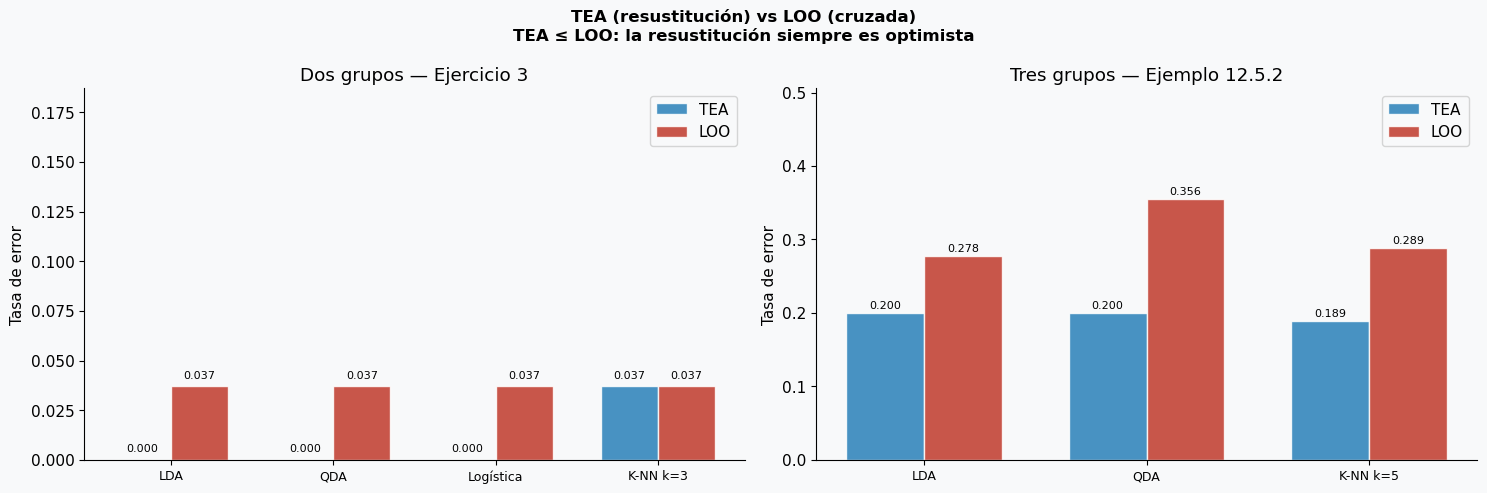

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, res, titulo in zip(
    axes,
    [resultados_2g, resultados_3g],
    ["Dos grupos — Ejercicio 3", "Tres grupos — Ejemplo 12.5.2"]
):
    mets = list(res.keys())
    teas = [res[m][0] for m in mets]
    loos = [res[m][1] for m in mets]
    xp = np.arange(len(mets)); w = 0.35
    b1 = ax.bar(xp-w/2, teas, w, label="TEA", color=C2, alpha=0.85, edgecolor="white")
    b2 = ax.bar(xp+w/2, loos, w, label="LOO", color=C1, alpha=0.85, edgecolor="white")
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.003,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xp); ax.set_xticklabels(mets, fontsize=9)
    ax.set_ylabel("Tasa de error"); ax.set_title(titulo)
    ax.legend(); ax.set_ylim(0, max(max(teas),max(loos))+0.15)

plt.suptitle("TEA (resustitución) vs LOO (cruzada)\n"
             "TEA ≤ LOO: la resustitución siempre es optimista",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 11. Resumen final

In [24]:
print("=" * 60)
print("  RESUMEN — DOS GRUPOS (Ejercicio 3, Tabla 12.7)")
print("=" * 60)
print(f"  Nueva obs. X₀ = {x_nueva}")
print(f"  {'Método':<20}  Asig.   P(G₁|X)  P(G₂|X)")
print(f"  {'─'*20}  {'─'*6}  {'─'*8}  {'─'*8}")

lda_f = LDA(solver='lsqr'); lda_f.fit(X_ej3, y_ej3)
qda_f = QDA();              qda_f.fit(X_ej3, y_ej3)
log_f = LogisticRegression(max_iter=500); log_f.fit(X_ej3, y_ej3)
knn_f = KNeighborsClassifier(n_neighbors=3); knn_f.fit(X_ej3, y_ej3)

for nom, m in [("LDA",lda_f),("QDA",qda_f),("Logística",log_f),("K-NN k=3",knn_f)]:
    p = m.predict([x_nueva])[0]
    pr = m.predict_proba([x_nueva])[0]
    print(f"  {nom:<20}  Pob.{p}   {pr[0]:.4f}   {pr[1]:.4f}")

print()
print("=" * 60)
print("  RESUMEN — TRES GRUPOS (Ejemplo 12.5.2, Futbolistas)")
print("=" * 60)
print(f"  Nueva obs. X₀ = {x_nueva_3g}")
print(f"  {'Método':<14}  Asig.   P(G₁)   P(G₂)   P(G₃)")
print(f"  {'─'*14}  {'─'*6}  {'─'*7}  {'─'*7}  {'─'*7}")

lda_3f = LDA(); lda_3f.fit(X_3g, y_3g)
qda_3f = QDA(); qda_3f.fit(X_3g, y_3g)
knn_3f = KNeighborsClassifier(n_neighbors=5); knn_3f.fit(X_3g, y_3g)

for nom, m in [("LDA",lda_3f),("QDA",qda_3f),("K-NN k=5",knn_3f)]:
    p  = m.predict([x_nueva_3g])[0]
    pr = m.predict_proba([x_nueva_3g])[0]
    print(f"  {nom:<14}  G{p}      {pr[0]:.4f}  {pr[1]:.4f}  {pr[2]:.4f}")

  RESUMEN — DOS GRUPOS (Ejercicio 3, Tabla 12.7)
  Nueva obs. X₀ = [26.71 17.04 25.73]
  Método                Asig.   P(G₁|X)  P(G₂|X)
  ────────────────────  ──────  ────────  ────────
  LDA                   Pob.1   0.9952   0.0048
  QDA                   Pob.1   0.9991   0.0009
  Logística             Pob.1   0.9835   0.0165
  K-NN k=3              Pob.1   1.0000   0.0000

  RESUMEN — TRES GRUPOS (Ejemplo 12.5.2, Futbolistas)
  Nueva obs. X₀ = [154 556 187  63  58 119]
  Método          Asig.   P(G₁)   P(G₂)   P(G₃)
  ──────────────  ──────  ───────  ───────  ───────
  LDA             G2      0.4040  0.4346  0.1613
  QDA             G1      0.5269  0.3062  0.1669
  K-NN k=5        G2      0.0000  1.0000  0.0000


---
### Tabla resumen de métodos

| Método | Supuesto | Frontera | Cuándo usar |
|---|---|---|---|
| **LDA** | Σ₁=…=Σₖ | Lineal (recta/hiperplano) | Grupos con covarianzas similares o n pequeño |
| **QDA** | Σᵢ distintas | Cuadrática (curva) | Covarianzas claramente distintas y n grande |
| **Logística** | Ninguno paramétrico | Lineal (en el puntaje) | Datos binarios, mixtos o no normales |
| **K-NN** | Ninguno | Irregular | Distribuciones complejas, no paramétricas |

> **TEA ≤ LOO siempre**: la resustitución es optimista porque clasifica los mismos datos usados para ajustar la regla.
